# Modos de cifrado para el AES

**Alumno:** Carlos Yanes Pérez

Se hace uso de los modos de cifrado ECB y CBC junto con el AES, para mostrar la peligrosidad de usar un modo inapropiado.

> Código refactorizado mediante IA.

In [1]:
!pip install pycryptodome pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 17.7 MB/s eta 0:00:00


## Obtener imagen del repositorio

In [8]:
import requests

# URL del archivo raw de la imagen en GitHub
ejemplo = "ejemplo4.jpg"
image_url = f"https://raw.githubusercontent.com/alu0101430720/TFM-CarlosYanesPerez/main/ModosCifradoAES/{ejemplo}"

# Nombre del archivo local para guardar la imagen
local_filename = ejemplo

# Realizar la solicitud HTTP para descargar la imagen
response = requests.get(image_url)

# Verificar que la solicitud fue exitosa (código de estado 200)
if response.status_code == 200:
    # Guardar el contenido de la respuesta en un archivo local
    with open(local_filename, 'wb') as f:
        f.write(response.content)
    print(f"Imagen '{local_filename}' descargada exitosamente.")
else:
    print(f"Error al descargar la imagen. Código de estado: {response.status_code}")

Imagen 'ejemplo4.jpg' descargada exitosamente.


## Aplicar modos de cifrado

In [9]:
import sys
import os
from PIL import Image, ImageDraw
from Crypto.Cipher import AES
from Crypto.Random import get_random_bytes

# ── Configuración ────────────────────────────────────────────────────────────
KEY = get_random_bytes(16)
BLOCK_SIZE = 16


# ── 1. Generar imagen de prueba si no se pasa ninguna ────────────────────────
def crear_imagen_test(path="test_original.png", size=(256, 256)):
    """Crea una imagen simple con formas geométricas de alto contraste."""
    img = Image.new("RGB", size, color=(240, 240, 240))
    draw = ImageDraw.Draw(img)

    # Fondo con zonas de color uniforme
    draw.rectangle([20, 20, 120, 120], fill=(30, 80, 180))   # azul
    draw.rectangle([136, 20, 236, 120], fill=(200, 50, 50))  # rojo
    draw.rectangle([20, 136, 120, 236], fill=(50, 180, 80))  # verde
    draw.rectangle([136, 136, 236, 236], fill=(220, 180, 0)) # amarillo
    draw.ellipse([88, 88, 168, 168], fill=(255, 255, 255))    # círculo blanco central
    draw.text((95, 120), "AES", fill=(0, 0, 0))

    img.save(path)
    print(f"[+] Imagen de prueba creada: {path}")
    return path


# ── 2. Cifrar cuerpo de la imagen con AES-ECB ────────────────────────────────
def cifrar_ecb(imagen_path, salida_path="cifrada_ECB.png"):
    """
    Cifra los píxeles raw de la imagen con AES-ECB.
    La cabecera PNG/BMP queda intacta para que el visor pueda abrir el archivo.
    Para BMP esto es trivial (cabecera fija de 54 bytes).
    Para PNG/otros formatos trabajamos sobre los bytes raw de píxeles en memoria.
    """
    img = Image.open(imagen_path).convert("RGB")
    datos = bytearray(img.tobytes())   # bytes raw de píxeles (sin cabecera de formato)

    # Padding PKCS#7 para que sea múltiplo de 16
    padding = BLOCK_SIZE - (len(datos) % BLOCK_SIZE)
    datos += bytes([padding] * padding)

    # Cifrado ECB — cada bloque de 16 bytes se cifra INDEPENDIENTEMENTE
    cipher = AES.new(KEY, AES.MODE_ECB)
    cifrados = cipher.encrypt(bytes(datos))

    # Reconstruir imagen desde los bytes cifrados (descartamos el padding)
    n_pixels = img.width * img.height * 3
    img_cifrada = Image.frombytes("RGB", img.size, cifrados[:n_pixels])
    img_cifrada.save(salida_path)
    print(f"[+] Imagen cifrada con ECB guardada: {salida_path}")
    return img_cifrada


# ── 3. Cifrar con AES-CBC (referencia segura) ────────────────────────────────
def cifrar_cbc(imagen_path, salida_path="cifrada_CBC.png"):
    """
    Cifra con AES-CBC: cada bloque depende del anterior (IV aleatorio).
    El resultado es visualmente indistinguible del ruido aleatorio.
    """
    img = Image.open(imagen_path).convert("RGB")
    datos = bytearray(img.tobytes())

    padding = BLOCK_SIZE - (len(datos) % BLOCK_SIZE)
    datos += bytes([padding] * padding)

    iv = get_random_bytes(16)
    cipher = AES.new(KEY, AES.MODE_CBC, iv)
    cifrados = cipher.encrypt(bytes(datos))

    n_pixels = img.width * img.height * 3
    img_cifrada = Image.frombytes("RGB", img.size, cifrados[:n_pixels])
    img_cifrada.save(salida_path)
    print(f"[+] Imagen cifrada con CBC guardada: {salida_path}")
    return img_cifrada


# ── 4. Crear comparativa lado a lado ────────────────────────────────────────
def crear_comparativa(original_path, ecb_img, cbc_img, salida="comparativa.png"):
    original = Image.open(original_path).convert("RGB")
    w, h = original.size
    margin = 10
    label_h = 30
    total_w = w * 3 + margin * 4
    total_h = h + margin * 2 + label_h

    comparativa = Image.new("RGB", (total_w, total_h), color=(30, 30, 30))

    # Pegar imágenes
    comparativa.paste(original, (margin, label_h + margin))
    comparativa.paste(ecb_img,  (w + margin * 2, label_h + margin))
    comparativa.paste(cbc_img,  (w * 2 + margin * 3, label_h + margin))

    # Etiquetas
    draw = ImageDraw.Draw(comparativa)
    draw.text((margin + w // 2 - 25,      8), "ORIGINAL",  fill=(255, 255, 255))
    draw.text((w + margin * 2 + w // 2 - 35, 8), "AES-ECB ⚠",  fill=(255, 100, 100))
    draw.text((w * 2 + margin * 3 + w // 2 - 30, 8), "AES-CBC ✓", fill=(100, 255, 100))

    comparativa.save(salida)
    print(f"[+] Comparativa guardada: {salida}")


# ── Main ─────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    # Using 'images.jpg' as the input image as requested by the user.
    imagen_input = local_filename

    ecb = cifrar_ecb(imagen_input)
    cbc = cifrar_cbc(imagen_input)
    crear_comparativa(imagen_input, ecb, cbc)

    print("\nArchivos generados:")
    print("   · test_original.png  — imagen original")
    print("   · cifrada_ECB.png    — cifrado ECB (patrones visibles)")
    print("   · cifrada_CBC.png    — cifrado CBC (ruido aleatorio)")
    print("   · comparativa.png    — los tres juntos")
    print(f"\n   Clave AES usada (hex): {KEY.hex()}")

[+] Imagen cifrada con ECB guardada: cifrada_ECB.png
[+] Imagen cifrada con CBC guardada: cifrada_CBC.png
[+] Comparativa guardada: comparativa.png

Archivos generados:
   · test_original.png  — imagen original
   · cifrada_ECB.png    — cifrado ECB (patrones visibles)
   · cifrada_CBC.png    — cifrado CBC (ruido aleatorio)
   · comparativa.png    — los tres juntos

   Clave AES usada (hex): 52d274dce455307983ff5d11e7e795bd


## Visualización

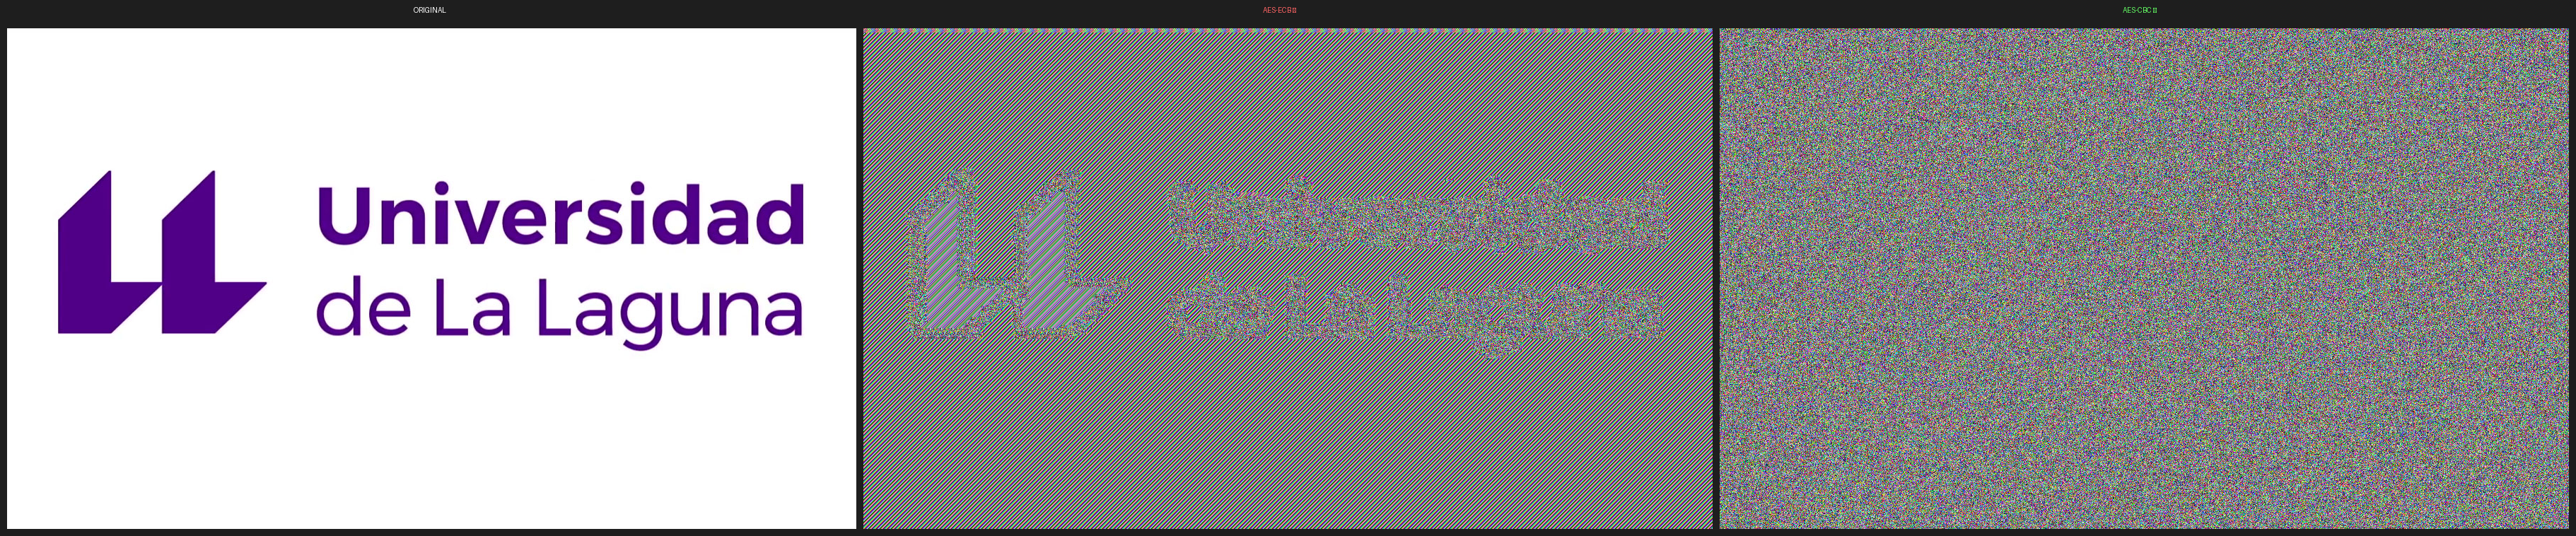

In [10]:
from IPython.display import Image
Image('comparativa.png')